<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Naive Bayes ....
<a class="anchor" id="1"></a> 

## Introduction

At first glance, the enrollment data may seem like mundane administrative records, but a deeper look reveals fascinating patterns in tuition dynamics and enrollment figures. This analysis delves into payment trends from March 2022 to March 2023 alongside various categorical attributes that describe the educational institutions and their students.

In [ ]:
# Import the required libraries and suppress warnings

import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
plt.switch_backend('Agg')

# Set aesthetic parameters for seaborn
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

## Data Loading and Understanding

We begin by loading the data from the file `peru_student_enrollment_data_2023.csv`. Note that the file uses a semicolon as the delimiter and is encoded in UTF-8-SIG. It contains a mix of numeric and categorical features along with information regarding tuition payments and enrollment details.

In [2]:
ls ../data  

HousePrice3.csv               heart.csv
Social_Network_Ads.csv        peru_student_enrollment_data_2023.csv
StudentsPerformance.csv       stock_data.csv
Students_Grading_Dataset.csv  student_Mat.csv
adult.csv


In [16]:
# Load the dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('../data/peru_student_enrollment_data_2023.csv', delimiter=';', encoding='UTF-8-SIG')

df.head()

,ENROLLMENT,TUITION PAYMENT MARCH 2022,TUITION PAYMENT MARCH 2023,GENDER,TYPE OF EDUCATIONAL INSTITUTION,EDUCATIONAL INSTITUTION,INSTITUTION STATUS,DEPARTMENT,PROVINCE,DISTRICT,...,CAMPUS,FACULTY,PROGRAM/MAJOR,SHIFT/SCHEDULE,BENEFIT DISCOUNTS,STUDY MODE,AGE RANGE OF ENROLLED STUDENT,DISABILITY,NUMBER OF ENROLLED COURSES,AT-RISK COURSE
0,Nuevo,0,0,M,INSTITUTO,IDAT,PRIVADA,LIMA,LIMA,BRENA,...,UTP Lima Centro,Fac. Ing. Sist. Y Elect.,ING. DE REDES Y COMUNICACIONES,MIXTO,SIN BENEFICIO,Presencial,5. >=30,No,0,0
1,Nuevo,1,0,M,COLEGIO,COLEGIO SISE,PRIVADA,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,...,UTP Lima Centro,Fac. Ing. Sist. Y Elect.,ING. DE SISTEMAS,NOCHE,SIN BENEFICIO,Presencial,4. 24-29,No,3,0
2,Nuevo,1,1,F,NaN,NaN,NaN,LIMA,LIMA,JESUS MARIA,...,UTP Lima Centro,Fac. Der. Cienc. Polit. Y RRII,DERECHO,NOCHE,SIN BENEFICIO,Presencial,4. 24-29,No,1,0
3,Nuevo,0,0,F,COLEGIO,1220 SAN JOSE MARELLO,ESTATAL,LIMA,LIMA,ATE,...,UTP Lima Centro,Fac. Adm. Y Neg.,ADMINISTRACION DE NEGOCIOS (50/50),NOCHE,SIN BENEFICIO,Presencial,4. 24-29,No,0,0
4,Nuevo,1,1,F,INSTITUTO,IDAT,PRIVADA,LIMA,LIMA,SURQUILLO,...,UTP Lima Centro,Fac. Adm. Y Neg.,ADM. DE NEGOCIOS INTERNACIO,MAÑANA,CONVENIOS,Presencial,4. 24-29,No,2,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37582 entries, 0 to 37581
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   ENROLLMENT                       37582 non-null  object
 1   TUITION PAYMENT MARCH 2022       37582 non-null  int64 
 2   TUITION PAYMENT MARCH 2023       37582 non-null  int64 
 3   GENDER                           37580 non-null  object
 4   TYPE OF EDUCATIONAL INSTITUTION  15868 non-null  object
 5   EDUCATIONAL INSTITUTION          18212 non-null  object
 6   INSTITUTION STATUS               15868 non-null  object
 7   DEPARTMENT                       36846 non-null  object
 8   PROVINCE                         36846 non-null  object
 9   DISTRICT                         36846 non-null  object
 10  CLASSIFICATION                   37581 non-null  object
 11  CAMPUS                           37582 non-null  object
 12  FACULTY                         

In [18]:
# missing values 
df.isnull().sum()/df.shape[0]*100

ENROLLMENT                          0.000000
TUITION PAYMENT MARCH 2022          0.000000
TUITION PAYMENT MARCH 2023          0.000000
GENDER                              0.005322
TYPE OF EDUCATIONAL INSTITUTION    57.777660
EDUCATIONAL INSTITUTION            51.540631
INSTITUTION STATUS                 57.777660
DEPARTMENT                          1.958384
PROVINCE                            1.958384
DISTRICT                            1.958384
CLASSIFICATION                      0.002661
CAMPUS                              0.000000
FACULTY                             0.002661
PROGRAM/MAJOR                       0.002661
SHIFT/SCHEDULE                      0.154329
BENEFIT DISCOUNTS                   0.000000
STUDY MODE                          0.000000
AGE RANGE OF ENROLLED STUDENT       0.010643
DISABILITY                          0.000000
NUMBER OF ENROLLED COURSES          0.000000
AT-RISK COURSE                      0.000000
dtype: float64

In [19]:
categorical_cols= df.select_dtypes("object").columns
categorical_cols

Index(['ENROLLMENT', 'GENDER', 'TYPE OF EDUCATIONAL INSTITUTION',
       'EDUCATIONAL INSTITUTION', 'INSTITUTION STATUS', 'DEPARTMENT',
       'PROVINCE', 'DISTRICT', 'CLASSIFICATION', 'CAMPUS', 'FACULTY',
       'PROGRAM/MAJOR', 'SHIFT/SCHEDULE', 'BENEFIT DISCOUNTS', 'STUDY MODE',
       'AGE RANGE OF ENROLLED STUDENT', 'DISABILITY'],
      dtype='object')

In [20]:
#  turn Object to Category type


for col in categorical_cols:
    df[col] = df[col].astype('category')

# Confirm the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37582 entries, 0 to 37581
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ENROLLMENT                       37582 non-null  category
 1   TUITION PAYMENT MARCH 2022       37582 non-null  int64   
 2   TUITION PAYMENT MARCH 2023       37582 non-null  int64   
 3   GENDER                           37580 non-null  category
 4   TYPE OF EDUCATIONAL INSTITUTION  15868 non-null  category
 5   EDUCATIONAL INSTITUTION          18212 non-null  category
 6   INSTITUTION STATUS               15868 non-null  category
 7   DEPARTMENT                       36846 non-null  category
 8   PROVINCE                         36846 non-null  category
 9   DISTRICT                         36846 non-null  category
 10  CLASSIFICATION                   37581 non-null  category
 11  CAMPUS                           37582 non-null  category
 12  FACU

## Exploratory Data Analysis

A thorough exploratory data analysis not only uncovers hidden relationships but also helps in verifying data quality. We will start by examining the correlations between numeric features. Our numeric subset includes the following columns:

- TUITION PAYMENT MARCH 2022
- TUITION PAYMENT MARCH 2023
- NUMBER OF ENROLLED COURSES
- AT-RISK COURSE

With four numeric columns on board, we have enough data for a robust correlation heatmap and pair plot. Additional visualizations include histograms, count plots, box plots, and violin plots to capture distributions and patterns in categorical data.

In [21]:
df.select_dtypes("number").corr()

,TUITION PAYMENT MARCH 2022,TUITION PAYMENT MARCH 2023,NUMBER OF ENROLLED COURSES,AT-RISK COURSE
TUITION PAYMENT MARCH 2022,1.000000,0.923384,0.038322,-0.186893
TUITION PAYMENT MARCH 2023,0.923384,1.000000,0.035174,-0.199271
NUMBER OF ENROLLED COURSES,0.038322,0.035174,1.000000,-0.007464
AT-RISK COURSE,-0.186893,-0.199271,-0.007464,1.000000


In [22]:
sns.set_theme(style='whitegrid', font_scale=1.1)

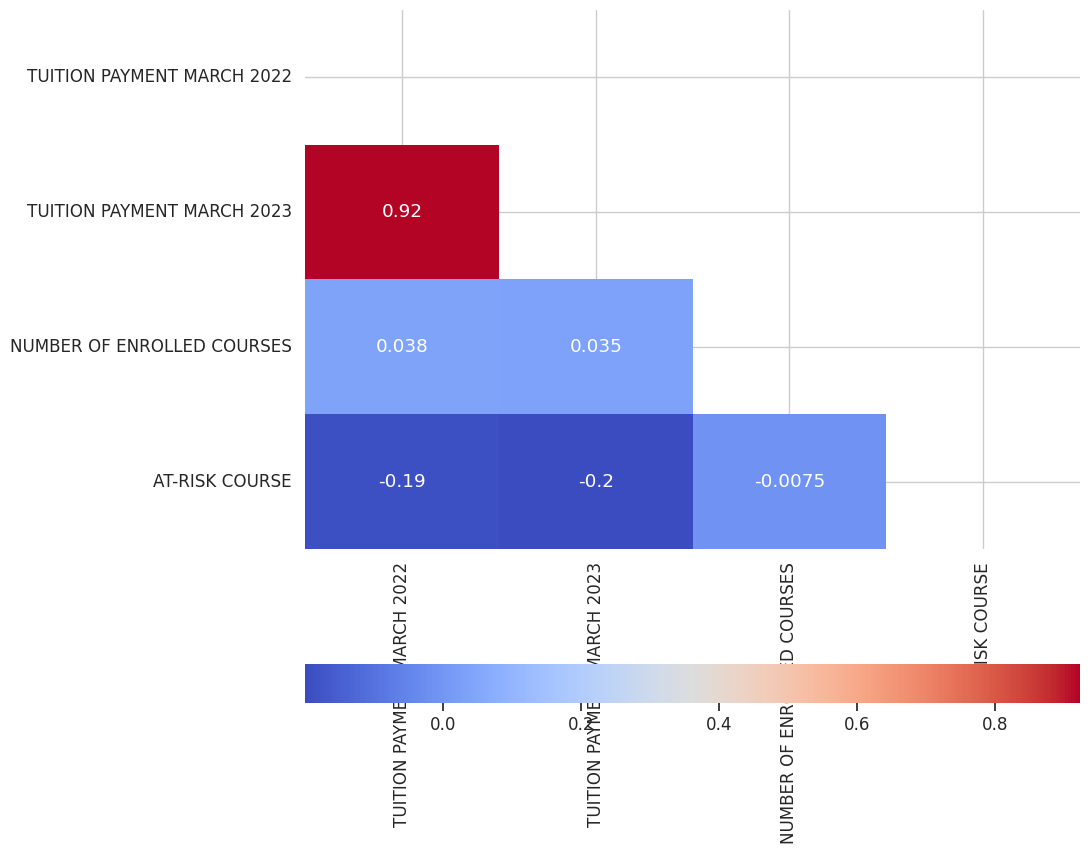

In [24]:
# sns correlation map. us matrix  mask  to avoid duplicate values

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
df_cor = df.select_dtypes("number") .corr()

matrix = np.triu(df_cor)
sns.heatmap(df_cor, mask=matrix, annot=True, cmap='coolwarm', cbar_kws={"orientation": "horizontal"}) 
plt.show()


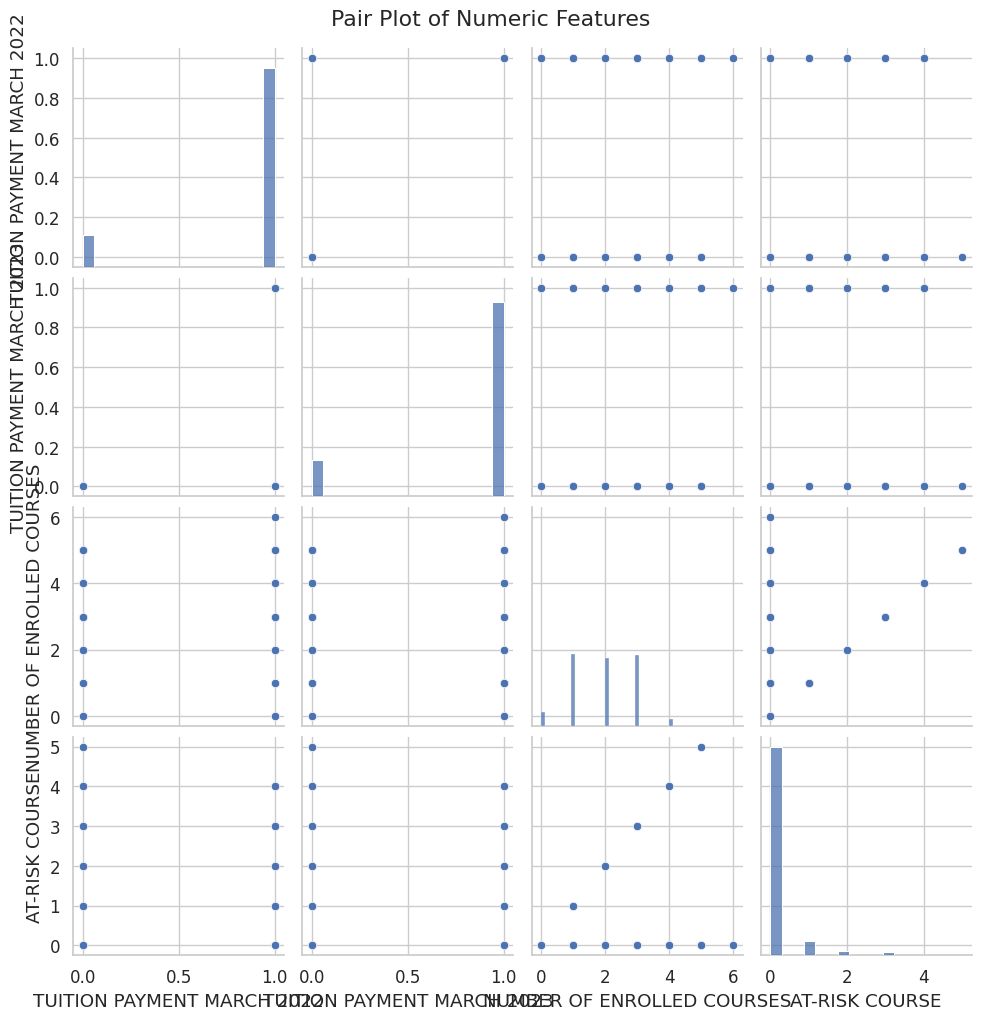

In [25]:
# Pair plot for numeric features
sns.pairplot(df.select_dtypes("number"))
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

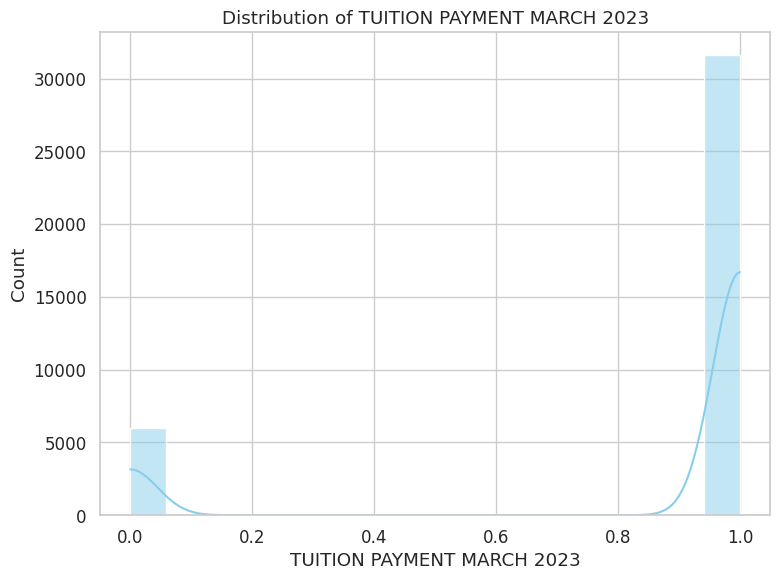

In [26]:
# Histogram of TUITION PAYMENT MARCH 2023
plt.figure(figsize=(8, 6))
sns.histplot(df['TUITION PAYMENT MARCH 2023'], kde=True, color='skyblue')
plt.title('Distribution of TUITION PAYMENT MARCH 2023')
plt.tight_layout()
plt.show()

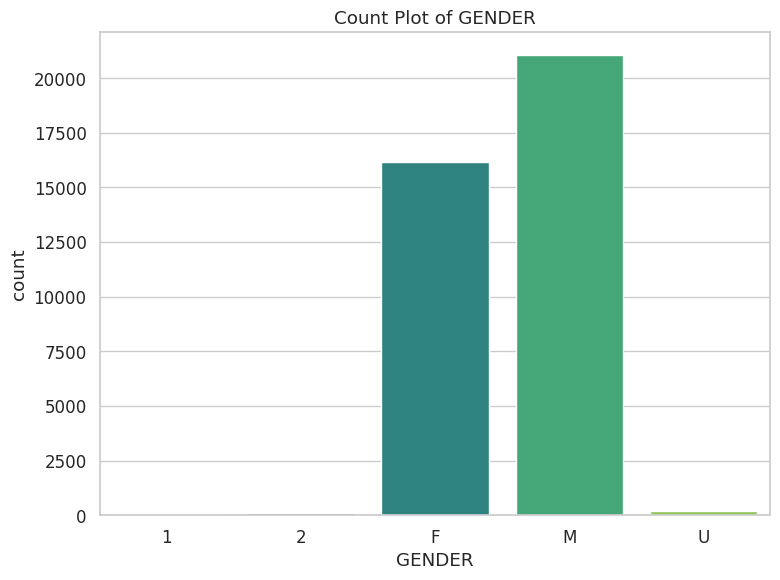

In [27]:
# Count plot (pie chart style) for GENDER
plt.figure(figsize=(8, 6))
sns.countplot(x='GENDER', data=df, palette='viridis') 
plt.title('Count Plot of GENDER')
plt.tight_layout()
plt.show()

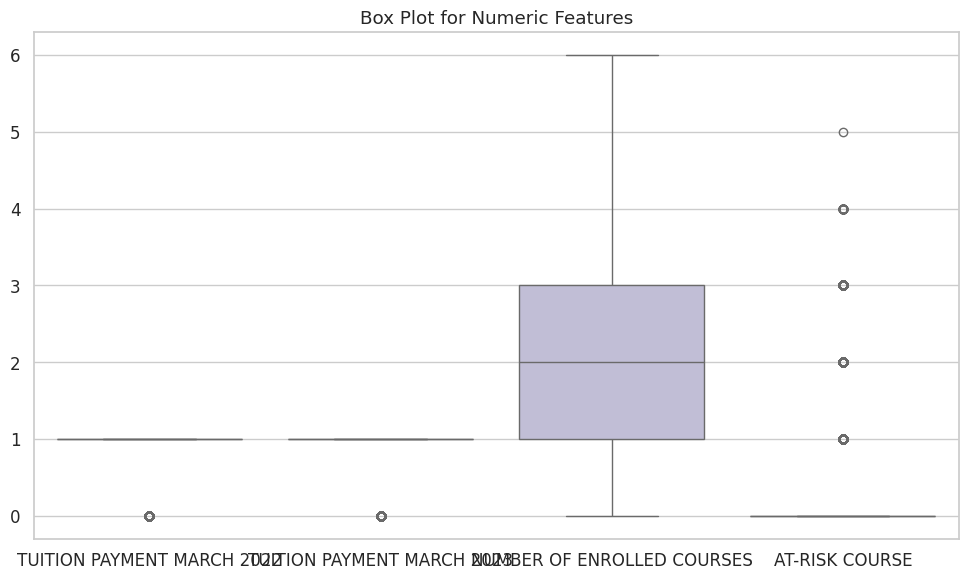

In [28]:
# Box plot for tuition payments
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.select_dtypes("number"), palette='Set3')
plt.title('Box Plot for Numeric Features')
plt.tight_layout()
plt.show()

In [29]:
df.GENDER.value_counts()

GENDER
M    21061
F    16149
U      201
2      102
1       67
Name: count, dtype: int64

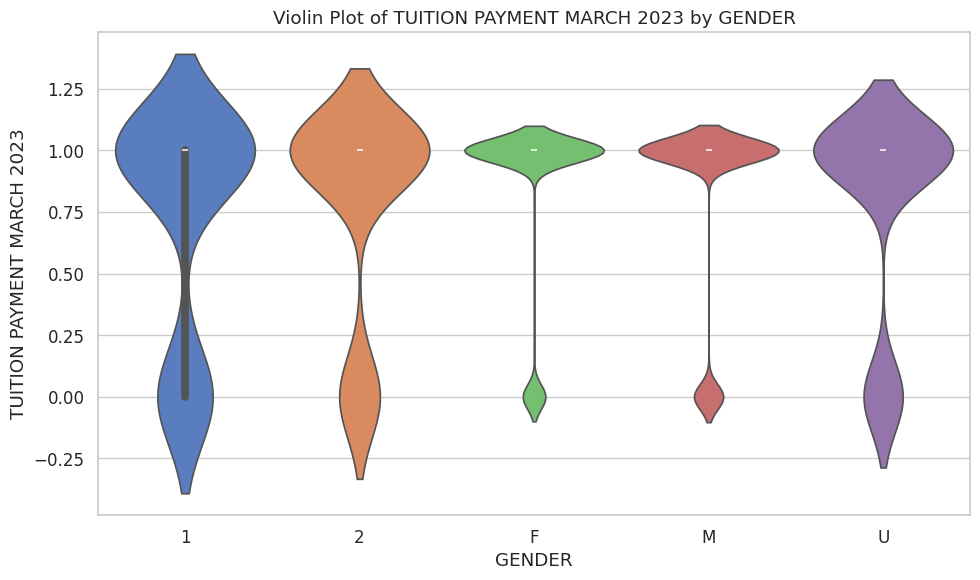

In [30]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='GENDER', y='TUITION PAYMENT MARCH 2023', hue='GENDER', data=df, palette='muted', legend=False)
plt.title('Violin Plot of TUITION PAYMENT MARCH 2023 by GENDER')
plt.tight_layout()
plt.show()

## Predictive Modeling

In this section we build a predictor to estimate the TUITION PAYMENT MARCH 2023 using available numeric features. The initial approach is to use a simple linear regression model. While multiple numeric columns are available, our primary features of interest include:

- TUITION PAYMENT MARCH 2022
- NUMBER OF ENROLLED COURSES
- AT-RISK COURSE

We split the data into training and test sets and evaluate performance using the R² score. An R² value closer to 1 indicates that the model explains much of the variability.

In [ ]:
# Import necessary libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define the predictor and target variables
features = ['TUITION PAYMENT MARCH 2022', 'NUMBER OF ENROLLED COURSES', 'AT-RISK COURSE']
target = 'TUITION PAYMENT MARCH 2023'

# Drop rows with missing values in the columns of interest
df_model = df.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

# Split the data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print('R² Score:', r2)
print('Mean Squared Error:', mse)

R² Score: 0.8531504243378049
Mean Squared Error: 0.0194066081853769


## Discussion and Future Work

Our analysis provided interesting insights into the patterns of tuition payment changes, enrollment numbers, and other institutional features. The linear regression model, though simplistic, demonstrated a measurable relationship between March 2022 and March 2023 tuition payments along with additional numeric predictors. Future work could include:

- Incorporating more categorical features using techniques such as one-hot encoding to improve predictive performance.
- Experimenting with more advanced modeling techniques such as Random Forests or Gradient Boosting Machines.
- Analyzing regional trends by grouping data based on departments or districts.
- Time series analysis, if additional date-related data becomes available.

In summary, this notebook used a multi-faceted approach for both exploratory analysis and predictive modeling. Although the methods applied here are just the beginning, they exemplify how a curious mind can extract valuable insights from seemingly routine data.